## 基于token num拟合TTFT和TPOT
+ 对于TTFT：所有seq的token num之和
+ 对于TPOT：batch_size

In [1]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from benchmark_test.analysis.profile.profile import InstanceProfile, InstanceDecodeProfiler
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt


Calculated avg_step_time for prefill, total 974 entries.
Calculated avg_step_time for decode, total 84 entries.
Lower bound: -225.88953588690077, Upper bound: 593.0823875325067
Filtered 0 outliers for prefill.
Lower bound: 26.119115350844545, Upper bound: 132.0840488966138
Filtered 0 outliers for decode.


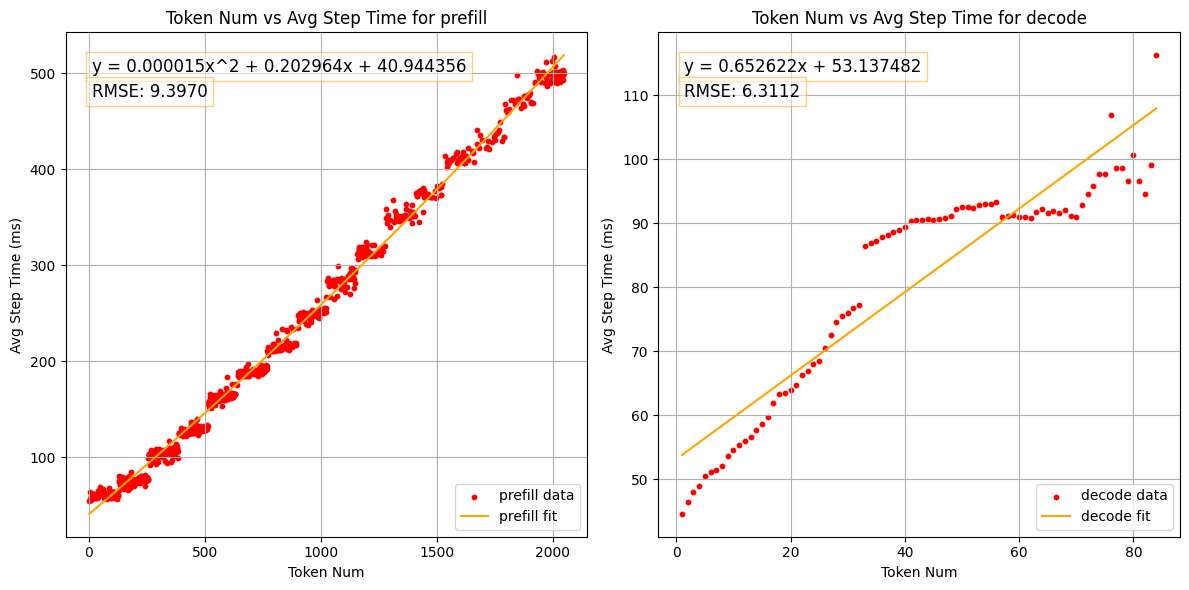

Calculated avg_step_time for prefill, total 974 entries.
Calculated avg_step_time for decode, total 157441 entries.
Lower bound: -225.88953588690077, Upper bound: 593.0823875325067
Filtered 0 outliers for prefill.
Lower bound: 28.09596061706543, Upper bound: 123.64459037780762
Filtered 175 outliers for decode.


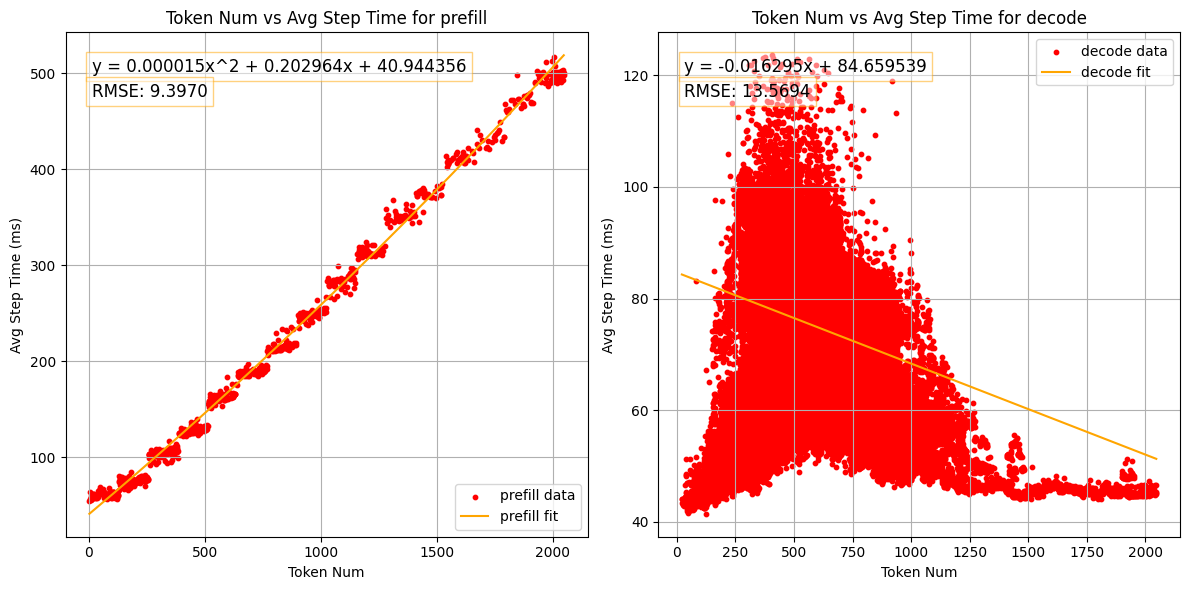

Calculated avg_step_time for prefill, total 974 entries.
Calculated avg_step_time for decode, total 22904 entries.
Lower bound: -225.88953588690077, Upper bound: 593.0823875325067
Filtered 0 outliers for prefill.
Lower bound: 18.782206047746477, Upper bound: 115.32668212900185
Filtered 0 outliers for decode.


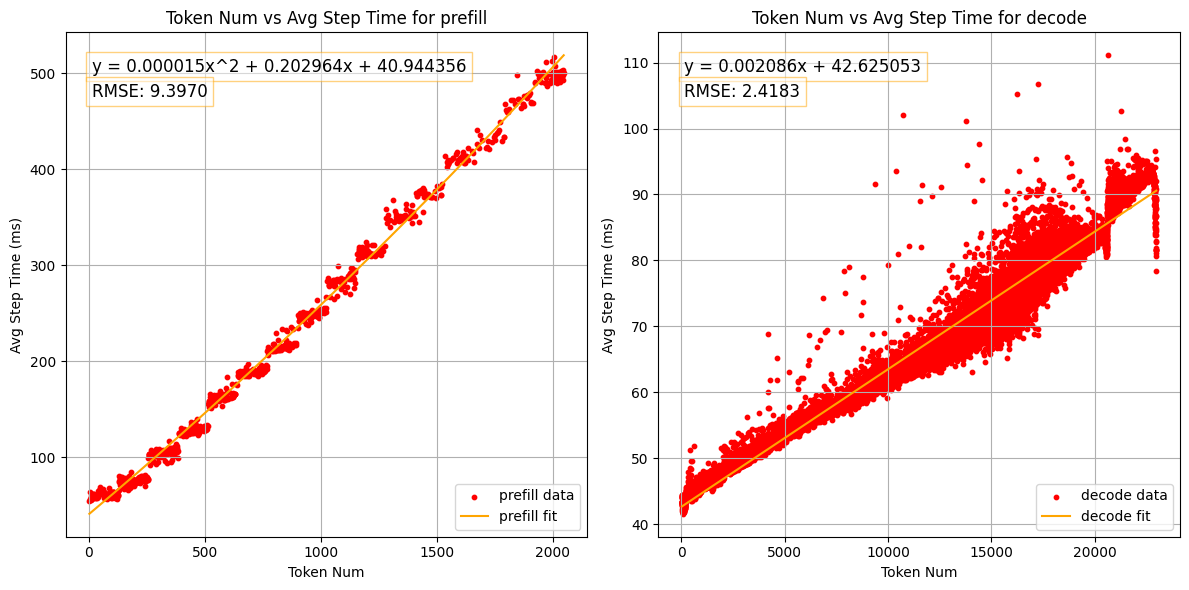

In [2]:
instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-13b/poisson'

# instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-test-128-256/llama-13b/poisson'
instance_profile = InstanceProfile(instance_file_dir,1, 0, enable_pd=True)
instance_profile.get_pdd_instance_info()
instance_profile.plot_token_num_vs_avg_step_time()
# instance_profile.fit_certain_data()

instance_profile = InstanceProfile(instance_file_dir,1, 1, enable_pd=True)
instance_profile.get_pdd_instance_info()
instance_profile.plot_token_num_vs_avg_step_time()

instance_profile = InstanceProfile(instance_file_dir,1, 2, enable_pd=True)
instance_profile.get_pdd_instance_info()
instance_profile.plot_token_num_vs_avg_step_time()

Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/TP2_instance_decode_profile_results.json
First key type: <class 'tuple'>, value type: <class 'list'>
Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/TP2_instance_decode_profile_v2_results.json
First key type: <class 'tuple'>, value type: <class 'list'>
x_val shape: (33871, 2), y_val shape: (33871,)
Lower bound: -97.98210859298706, Upper bound: 256.7146420478821
fit_results:18.343315250706105 + [0.23448892 0.00037641]
RMSE: 5.1610
filter_count: 0
x_val shape: (33710, 2), y_val shape: (33710,)
Lower bound: -96.95032238960266, Upper bound: 254.93571162223816
fit_results:18.336068374839073 + [0.23407698 0.00037725]
RMSE: 5.0522


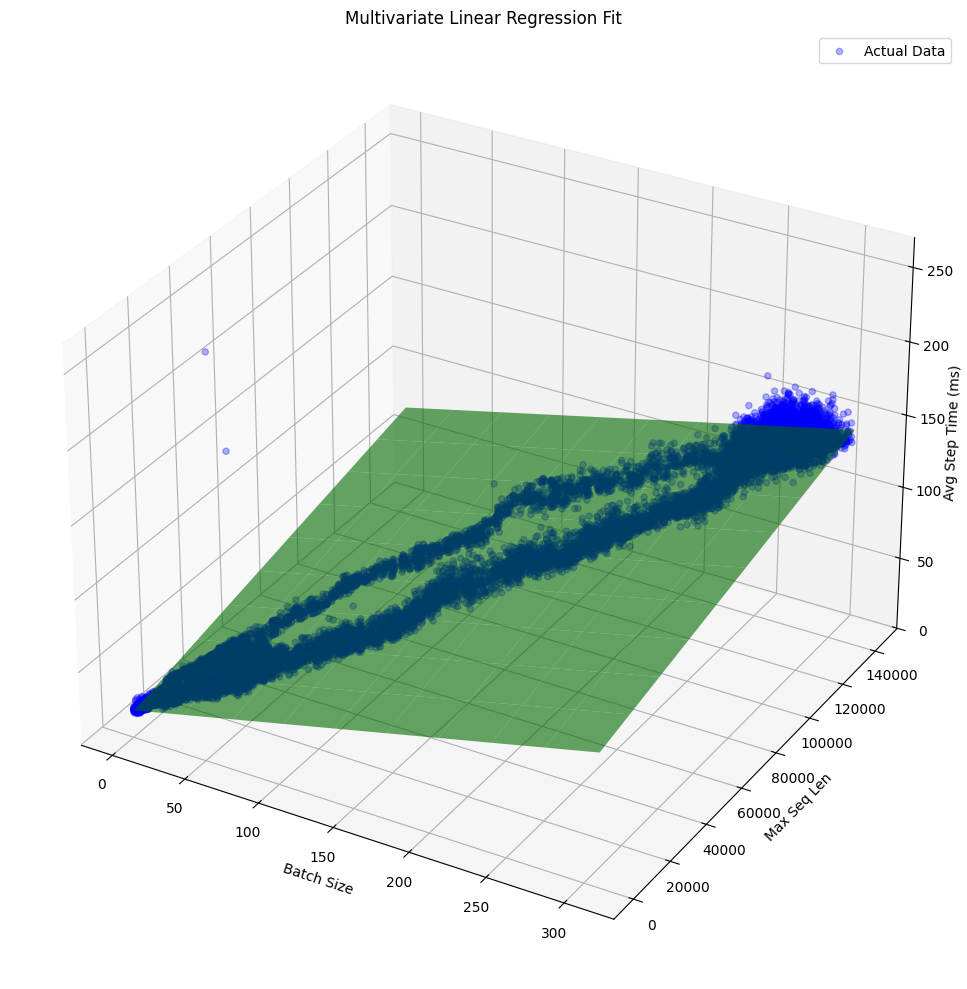

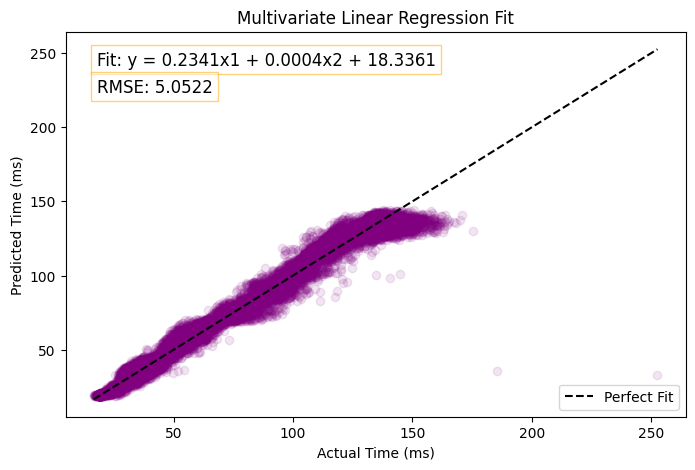

In [4]:
from benchmark_test.analysis.profile.profile import InstanceDecodeProfilerV2


instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson'
instance_profile = InstanceDecodeProfilerV2(instance_file_dir, tp=2, enable_pd=True, is_verbose=True)
instance_profile.get_pdd_instance_info()
print(f"filter_count: {instance_profile.filter_count}")
y_pred = instance_profile.plot_result()

# 对比原始数据与预测
y = instance_profile.y_values
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, c='purple', alpha=0.1, )
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Fit')
# 显示表达式
plt.text(0.05, 0.95, f'Fit: y = {instance_profile.model.coef_[0]:.4f}x1 + {instance_profile.model.coef_[1]:.4f}x2 + {instance_profile.model.intercept_:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.text(0.05, 0.88, f'RMSE: {instance_profile.rmse:.4f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.xlabel('Actual Time (ms)')
plt.ylabel('Predicted Time (ms)')
plt.title('Multivariate Linear Regression Fit')  # 多元线性拟合
plt.legend()
plt.show()

### 开题画图

In [9]:
# 拟合token_num和avg_step_time的关系
def fit_data(x, y):

    if len(x) < 2:
        print(f"Not enough data to fit.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    coefficients = np.polyfit(x, y, 2)

    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_data(x,y,x_label='Input Len', y_label='Decode Time (ms)', title='Input Len vs Decode Time (Batch Size: 32)'):
    # 分配两个子图
    fig, axs = plt.subplots(1, 1, figsize=(8, 6))

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    # 剔除异常值
    # if len(x) > 20:
    #     # 基于IQR方法剔除异常值
    #     q1 = np.percentile(y, 25)
    #     q3 = np.percentile(y, 75)
    #     iqr = q3 - q1
    #     lower_bound = q1 - 1.5 * iqr
    #     upper_bound = q3 + 1.5 * iqr
    #     print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    #     mask = (y >= lower_bound) & (y <= upper_bound)
    #     x = x[mask]
    #     y = y[mask]
    axs.scatter(x, y, color='red', s=20, label='Data Points', alpha=0.2)
    # 拟合曲线
    fit_results = fit_data(x, y)
    if fit_results is not None:
        print(f'Fitting results: {fit_results}')
        fit_line = np.polyval(fit_results, x)
        axs.plot(x, fit_line, color='orange')
        # 在图片上显示拟合结果
        fit_eq = f'y = {fit_results[0]:.6f}x^2 + {fit_results[1]:.6f}x + {fit_results[2]:.6f}'
        axs.text(0.05, 0.95, fit_eq, transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', )
        # 计算拟合的均方根误差
        rmse = np.sqrt(np.mean((y - fit_line) ** 2))
        print(f"RMSE: {rmse:.4f}")
        axs.text(0.05, 0.90, f'RMSE: {rmse:.4f}', transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', )
    axs.set_title(title)
    axs.set_xlabel(x_label)
    axs.set_ylabel(y_label)
    axs.legend()
    axs.grid(True)
    plt.tight_layout()
    plt.savefig(f'topic_proposal_prefill_token_num_vs_avg_step_time.png')
    plt.show()

# x = instance_profile.x_values[:,1]
# y = instance_profile.y_values
# plot_data(x, y, 'Max Input Len', 'Decode Time (ms)', f'Max Input Len vs Decode Time')

token_nums = list(instance_profile.avg_results['prefill'].keys())
avg_step_times = list(instance_profile.avg_results['prefill'].values())

token_nums = np.array(token_nums, dtype=float)
avg_step_times = np.array(avg_step_times, dtype=float)

plot_data(token_nums, avg_step_times, 'Token Num', 'Avg Step Time(ms)', f'')

KeyError: 'prefill'

## 基于batch_size和seq_len二元拟合TPOT

filter_count: 0


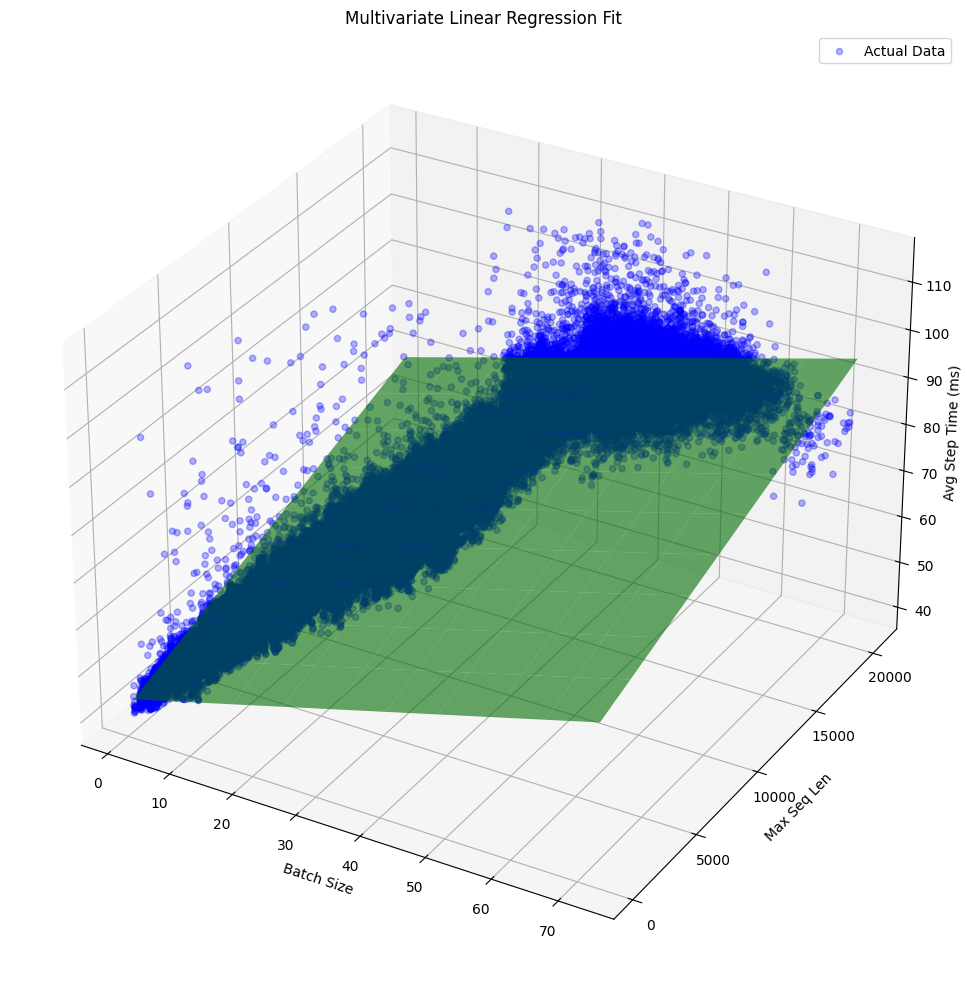

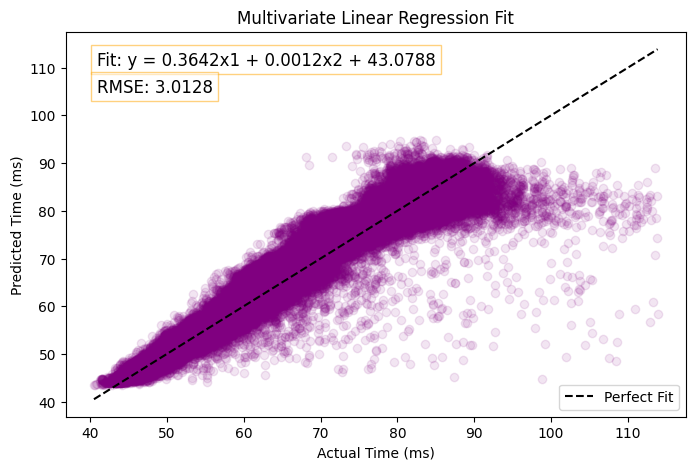

In [10]:
from benchmark_test.analysis.profile.profile import InstanceProfile, InstanceDecodeProfiler, InstanceDecodeProfilerV2
import matplotlib.pyplot as plt
instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-13b/poisson'
instance_profile = InstanceDecodeProfiler(instance_file_dir, tp=1, enable_pd=True)
instance_profile.get_pdd_instance_info()
print(f"filter_count: {instance_profile.filter_count}")
y_pred = instance_profile.plot_result()

# 对比原始数据与预测
y = instance_profile.y_values
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, c='purple', alpha=0.1, )
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Fit')
# 显示表达式
plt.text(0.05, 0.95, f'Fit: y = {instance_profile.model.coef_[0]:.4f}x1 + {instance_profile.model.coef_[1]:.4f}x2 + {instance_profile.model.intercept_:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.text(0.05, 0.88, f'RMSE: {instance_profile.rmse:.4f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.xlabel('Actual Time (ms)')
plt.ylabel('Predicted Time (ms)')
plt.title('Multivariate Linear Regression Fit')  # 多元线性拟合
plt.legend()
plt.show()


Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-13b/poisson/TP1_instance_decode_profile_results.json
First key type: <class 'tuple'>, value type: <class 'list'>
Found 9 instance files: ['benchmark_pdd_2000_qps-1_1,1,1-1_instance.csv', 'benchmark_pdd_2000_qps-1_1,1-1,1_instance.csv', 'benchmark_pdd_2000_qps-1_1-1,1,1_instance.csv', 'benchmark_pdd_2000_qps-2_1,1,1-1_instance.csv', 'benchmark_pdd_2000_qps-2_1,1-1,1_instance.csv', 'benchmark_pdd_2000_qps-2_1-1,1,1_instance.csv', 'benchmark_pdd_2000_qps-4_1,1,1-1_instance.csv', 'benchmark_pdd_2000_qps-4_1,1-1,1_instance.csv', 'benchmark_pdd_2000_qps-4_1-1,1,1_instance.csv']
[profile] Processing file: /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-13b/poisson/benchmark_pdd_2000_qps-1_1,1,1-1_instance.csv
Processing instance_id: 530b31efc56e466a809d8084fb8c88be, group size: 43687, inference_type: decode
Processing instance_id: 70740cd799d84df09efa0fc57c95af2

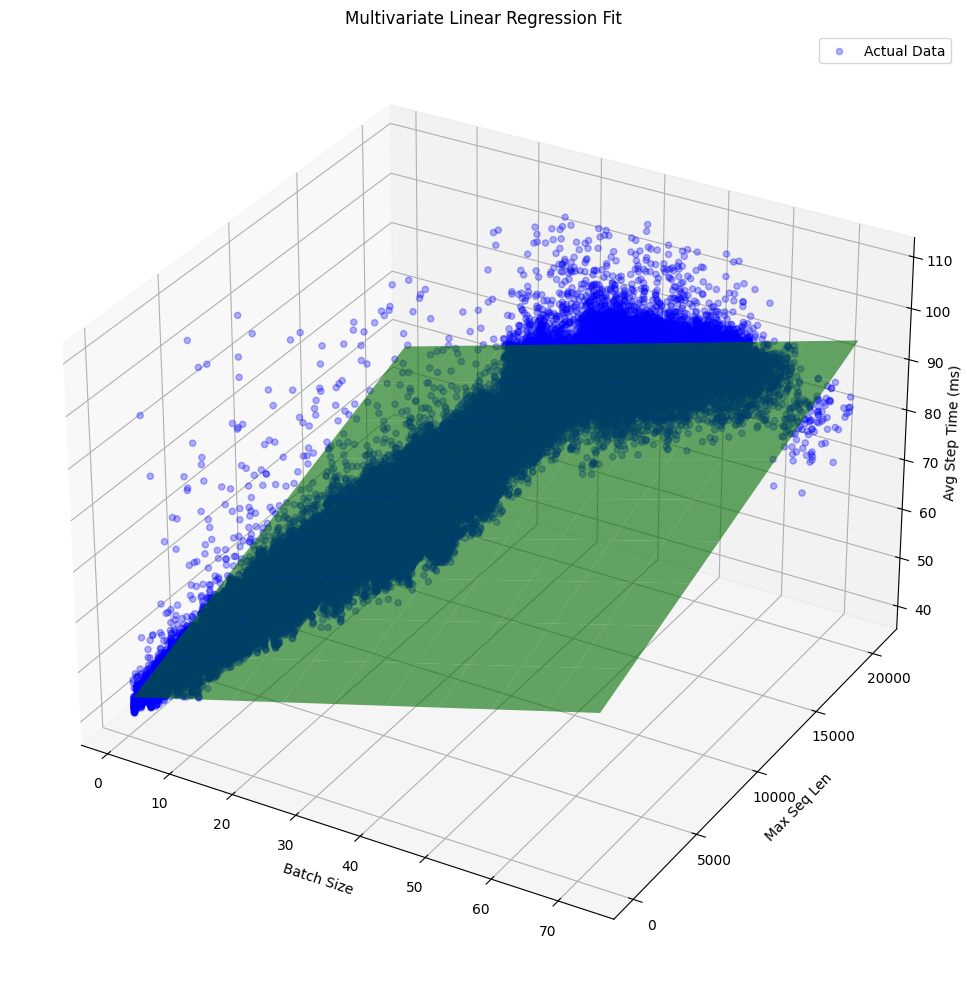

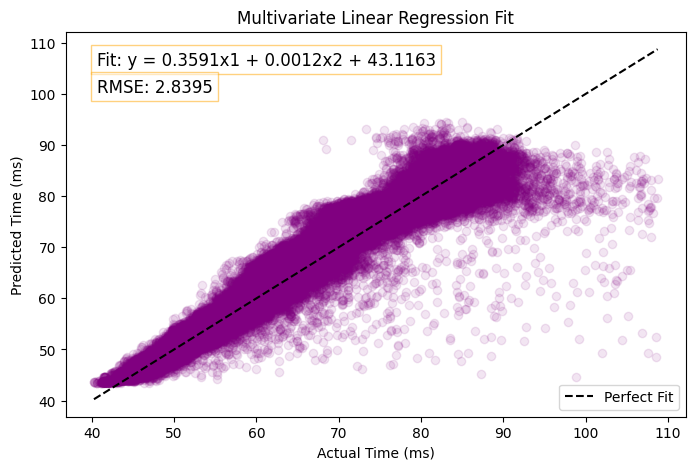

RMSE: 2.7005
Nonlinear Fit Parameters: [-1.38376666e-02 -6.85816281e-08  6.82956638e-05  1.45740433e-01
  1.43708673e-03  4.41157136e+01]
Expression: y = -0.013838x1^2 + -0.000000x2^2 + 0.000068x1x2 + 0.145740x1 + 0.001437x2 + 44.115714


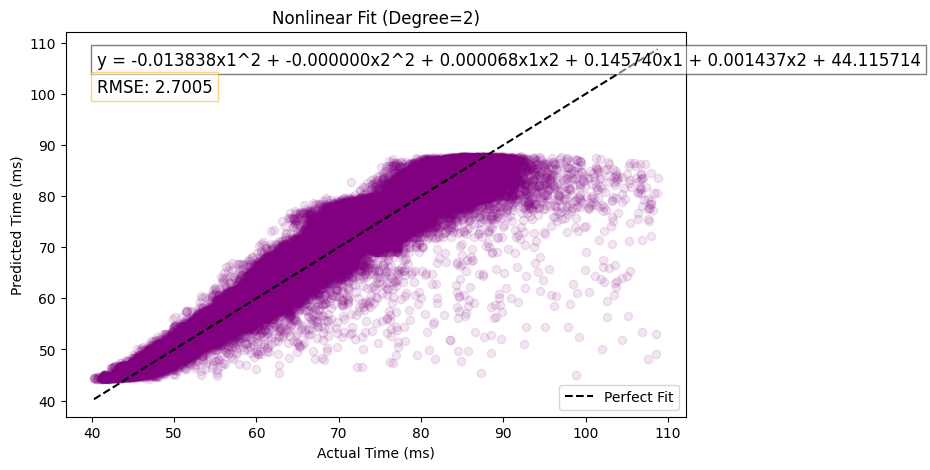

In [ ]:
from scipy.optimize import curve_fit

# 定义非线性模型（示例：二次函数含交互项）
def nonlinear_model(X, a, b, c, d, e, f):
    x1, x2 = X[:, 0], X[:, 1]
    return a * x1**2 + b * x2**2 + c * x1 * x2 + d * x1 + e * x2 + f
X = instance_profile.x_values
y = instance_profile.y_values
# 拟合非线性模型
params, _ = curve_fit(nonlinear_model, X, y, p0=[1, 1, 1, 1, 1, 1])
y_pred_nl = nonlinear_model(X, *params)
# print(nonlinear_model(np.array([[18.66, 256]]), *params))  # 测试预测
# 计算拟合的均方根误差
rmse = np.sqrt(np.mean((y-y_pred_nl) ** 2))
print(f"RMSE: {rmse:.4f}")
print(f"Nonlinear Fit Parameters: {params}")
# 对比原始数据与预测
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_nl, c='purple', alpha=0.1, )
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Fit')
# 显示表达式
expression = f"y = {params[0]:.6f}x1^2 + {params[1]:.6f}x2^2 + {params[2]:.6f}x1x2 + {params[3]:.6f}x1 + {params[4]:.6f}x2 + {params[5]:.6f}"
print(f"Expression: {expression}")
plt.text(0.05, 0.95, expression, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
plt.text(0.05, 0.88, f'RMSE: {rmse:.4f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
plt.xlabel('Actual Time (ms)')
plt.ylabel('Predicted Time (ms)')
plt.title('Nonlinear Fit (Degree=2)')
plt.legend()
plt.show()


Polynomial Fit RMSE: 2.7005


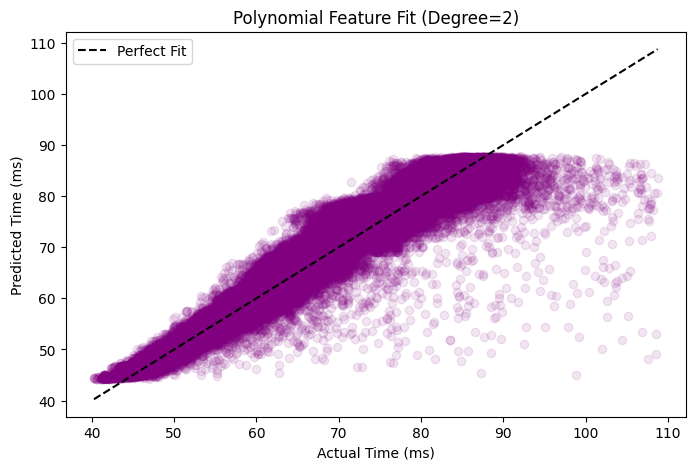

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# 生成二阶多项式特征（含交互项）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 拟合扩展后的线性模型
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
y_pred_poly = model_poly.predict(X_poly)
# 计算拟合的均方根误差
rmse_poly = np.sqrt(np.mean((y - y_pred_poly) ** 2))
print(f"Polynomial Fit RMSE: {rmse_poly:.4f}")

# 对比原始数据与预测
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_poly, c='purple', alpha=0.1, )
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='Perfect Fit')
plt.xlabel('Actual Time (ms)')
plt.ylabel('Predicted Time (ms)')
plt.title('Polynomial Feature Fit (Degree=2)')
plt.legend()
plt.show()


x.shape: (368902,), y.shape: (368902,)
Fitting results: [4.61711567e-05 5.97799898e-01 2.75998439e+01]
RMSE: 8.0461


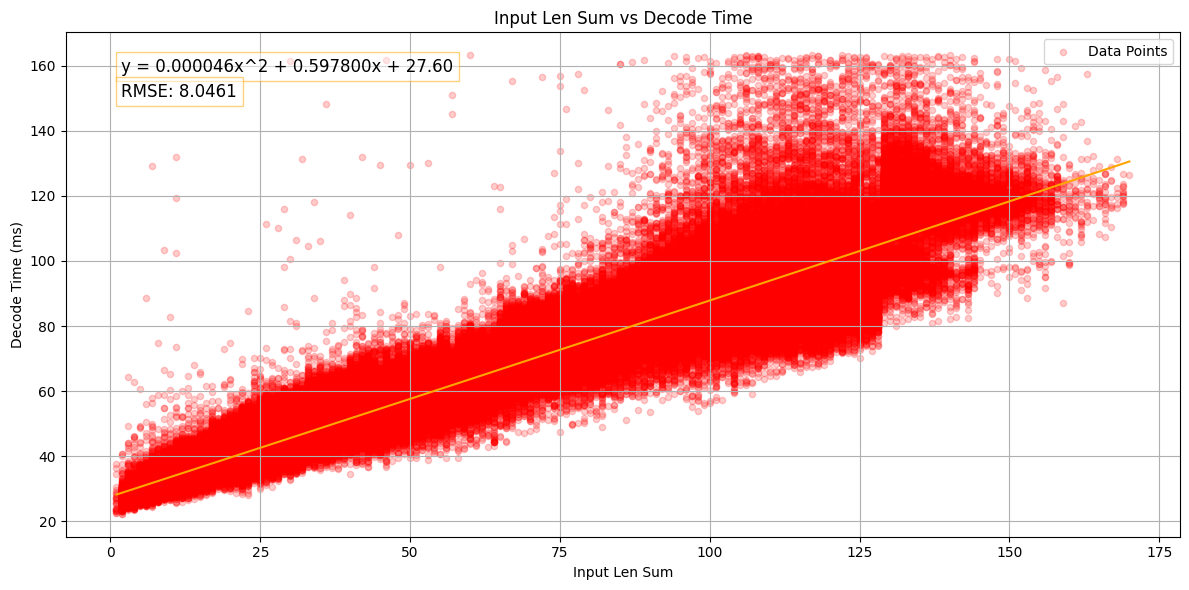

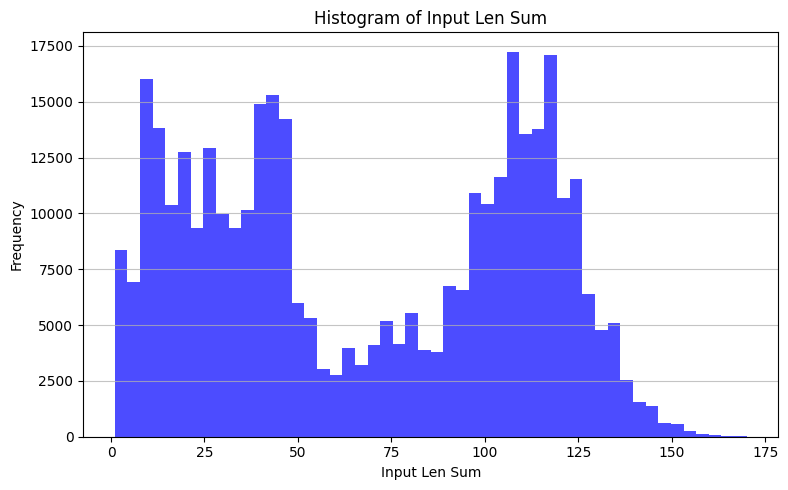

In [ ]:
# 拟合token_num和avg_step_time的关系
def fit_data(x, y):

    if len(x) < 2:
        print(f"Not enough data to fit.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    coefficients = np.polyfit(x, y, 2)

    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_data(x,y,x_label='Input Len', y_label='Decode Time (ms)', title='Input Len vs Decode Time (Batch Size: 32)'):
    # 分配两个子图
    fig, axs = plt.subplots(1, 1, figsize=(12, 6))

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    # 剔除异常值
    # if len(x) > 20:
    #     # 基于IQR方法剔除异常值
    #     q1 = np.percentile(y, 25)
    #     q3 = np.percentile(y, 75)
    #     iqr = q3 - q1
    #     lower_bound = q1 - 1.5 * iqr
    #     upper_bound = q3 + 1.5 * iqr
    #     print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    #     mask = (y >= lower_bound) & (y <= upper_bound)
    #     x = x[mask]
    #     y = y[mask]
    axs.scatter(x, y, color='red', s=20, label='Data Points', alpha=0.2)
    # 拟合曲线
    fit_results = fit_data(x, y)
    if fit_results is not None:
        print(f'Fitting results: {fit_results}')
        fit_line = np.polyval(fit_results, x)
        axs.plot(x, fit_line, color='orange')
        # 在图片上显示拟合结果
        fit_eq = f'y = {fit_results[0]:.6f}x^2 + {fit_results[1]:.6f}x + {fit_results[2]:.2f}'
        axs.text(0.05, 0.95, fit_eq, transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
        # 计算拟合的均方根误差
        rmse = np.sqrt(np.mean((y - fit_line) ** 2))
        print(f"RMSE: {rmse:.4f}")
        axs.text(0.05, 0.90, f'RMSE: {rmse:.4f}', transform=axs.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(facecolor='white', edgecolor='orange', alpha=0.5))
    axs.set_title(title)
    axs.set_xlabel(x_label)
    axs.set_ylabel(y_label)
    axs.legend()
    axs.grid(True)
    plt.tight_layout()
    # plt.savefig(f'token_num_vs_avg_step_time.png')
    plt.show()

# x = instance_profile.x_values[:,1]
# y = instance_profile.y_values
# plot_data(x, y, 'Max Input Len', 'Decode Time (ms)', f'Max Input Len vs Decode Time')

instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson'
instance_profile = InstanceDecodeProfiler(instance_file_dir, tp=1, enable_pd=True)
instance_profile.get_pdd_instance_info()

x = instance_profile.bs
y = instance_profile.y_values
# x只取小于等于256的值，首先获取索引
valid_indices = np.where(x <= 100000)[0]
# x1 = x[valid_indices]
# y1 = y[valid_indices]

x1 = x
y1 = y

print(f'x.shape: {x1.shape}, y.shape: {y1.shape}')
plot_data(x1, y1, 'Input Len Sum', 'Decode Time (ms)', f'Input Len Sum vs Decode Time')
# for idx in valid_indices:
#     print(f"Index: {idx}, {instance_profile.x_values[idx]}, Input Len Sum: {x[idx]}, Decode Time: {y[idx]}")
# 绘制x1直方图
plt.figure(figsize=(8, 5))
plt.hist(x1, bins=50, color='blue', alpha=0.7)
plt.xlabel('Input Len Sum')
plt.ylabel('Frequency')
plt.title('Histogram of Input Len Sum')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## 基于req_len和e2e时延建模TTFT

## 基于block_num拟合迁移时间

{1: 84.25520782200795, 2: 97.10432030040131, 3: 111.53820745662443, 4: 123.62958967071219, 5: 133.07915336784276, 6: 138.20179265279037, 7: 150.15592800794974, 8: 159.80937236394638, 9: 169.6669374193464, 10: 175.60720906674283, 11: 175.24542884221154, 12: 209.8753064177757, 13: 194.11992315036147, 14: 210.99445737641435, 15: 223.90997835568018, 16: 222.98767226082938, 17: 226.9453748743585, 18: 241.06904176565317, 19: 256.06831908226013, 20: 224.07987382676868, 21: 252.7149985818302, 22: 258.11416928361103, 23: 282.55572685828577, 24: 304.41970295376245, 25: 283.9922606945038, 26: 302.6265914623554, 27: 325.22288390568326, 28: 310.22360745598286, 29: 310.9701801748837, 30: 307.61956084858286, 31: 328.8284460703532, 32: 368.1515955155896, 33: 361.596521578337, 34: 362.76599764823914, 35: 355.16993204752606, 36: 351.10494068690707, 37: 355.5399775505066, 38: 407.40962823232013, 39: 383.51556989881726, 40: 390.92767238616943, 41: 375.9172856807709, 42: 382.4961185455322, 43: 457.51179754

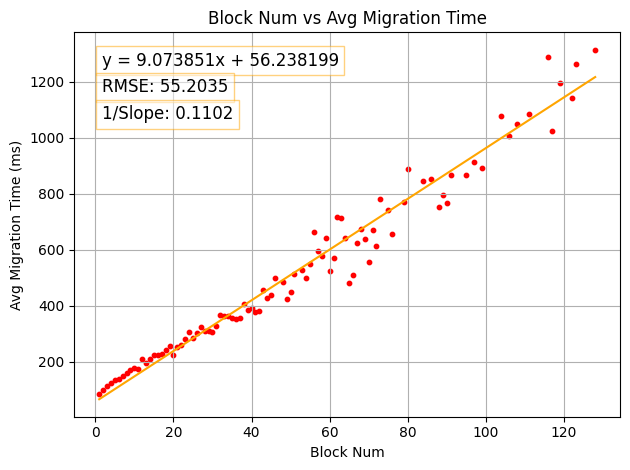

In [4]:
from benchmark_test.analysis.profile.profile import MigrationProfile
concurrency = 1
model = 'llama-13b'
file = [
    # f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps-6_1-1,1,1.log',
    # f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps-2_1-1,1,1.log',
    # f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps-4_1-1,1,1.log',
    f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps-6_1,1,1-1.log',
    f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps-2_1,1,1-1.log',
    f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}/{model}/poisson/benchmark_pdd_2000_qps-4_1,1,1-1.log',
]
migration_profile = MigrationProfile(file)
migration_profile.get_migration_info()
print(migration_profile.avg_results)
migration_profile.plot_block_num_vs_avg_migration_time()

{1: 152.66572104560004, 2: 128.8257211232357, 3: 154.35213286702225, 4: 136.39457632855672, 5: 147.86488734758817, 6: 124.2846662347967, 7: 157.7072956345298, 8: 145.48925695748164, 9: 178.23272281222873, 10: 165.79709381892764, 11: 197.98419393342118, 12: 173.77806663513184, 13: 277.0641088485718, 14: 246.12673123677573, 15: 238.4179339689367, 16: 224.8999902180263, 17: 245.641999774509, 18: 233.84199823651994, 19: 282.6332679161659, 20: 466.1048650741577, 21: 293.96629333496094, 22: 687.190055847168, 23: 393.0880308151245, 24: 297.9360103607178, 25: 228.74301671981812, 26: 381.8087577819824, 27: 527.2209644317627, 28: 362.04981803894043, 29: 306.44019444783527, 31: 582.5977325439453, 32: 397.78931935628253, 33: 467.4936532974243, 34: 254.68969345092773, 35: 340.09015560150146, 36: 250.8801817893982, 37: 241.46270751953125, 38: 303.952693939209, 39: 238.07358741760254, 40: 238.6461098988851, 41: 252.39109992980957, 42: 302.8832674026489, 43: 404.4378995895386, 45: 384.2407464981079, 4

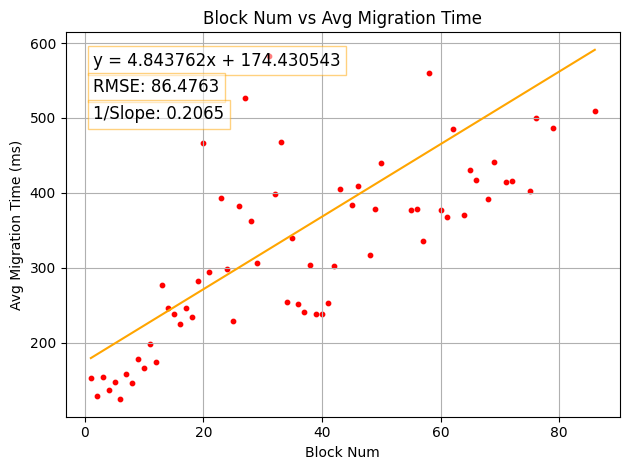

In [ ]:
file = [
    '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-test-concurrency-4-128-256/llama-13b/poisson/serve_pdd_1000_qps_16_1_1,1,1.log',
]
migration_profile = MigrationProfile(file)
migration_profile.get_migration_info()
print(migration_profile.avg_results)
migration_profile.plot_block_num_vs_avg_migration_time()

Lower bound: -30.12770796433483, Upper bound: 873.1517615990763
Lower bound: -130.4084062576294, Upper bound: 918.0029630661011


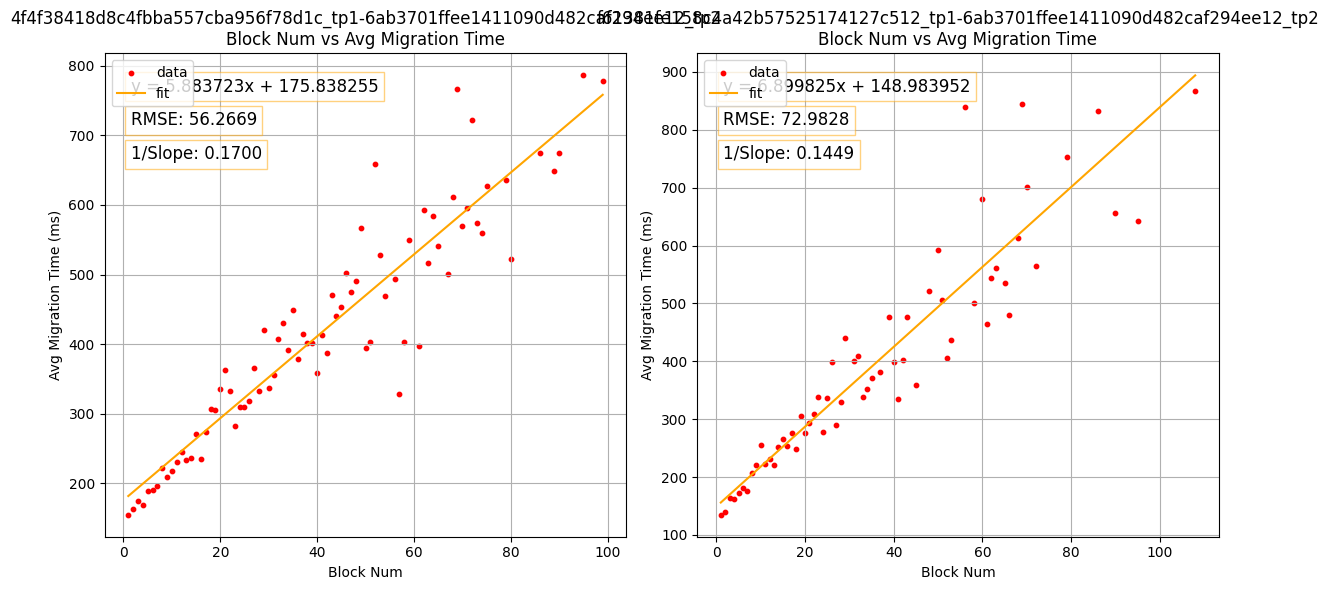

Lower bound: 7.562611252069473, Upper bound: 719.2935384809971


<Figure size 640x480 with 0 Axes>

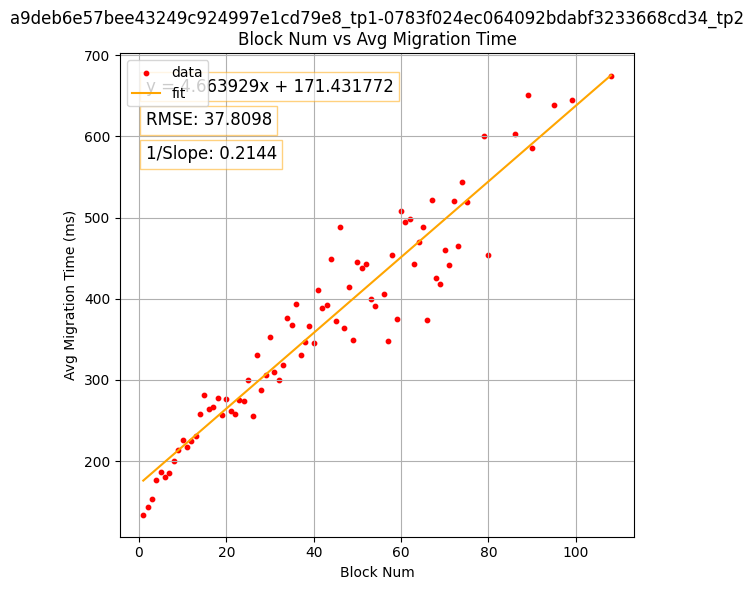

<Figure size 640x480 with 0 Axes>

In [5]:
from benchmark_test.analysis.profile.profile import MigrationProfile, MigrationProfileV2


file = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/benchmark_pdd_2000_qps-4_1,1-2.log'
migration_profile = MigrationProfileV2(file)
migration_profile.get_migration_info()
migration_profile.plot_block_num_vs_avg_migration_time()

file = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/benchmark_pdd_2000_qps-4_1-2.log'
migration_profile = MigrationProfileV2(file)
migration_profile.get_migration_info()
migration_profile.plot_block_num_vs_avg_migration_time()


## profile汇总

In [ ]:
from benchmark_test.analysis.profile.profile import MigrationProfile
from benchmark_test.analysis.profile.profile import InstanceProfile, InstanceDecodeProfiler
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt
import yaml
import os

In [ ]:
profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4'

# [migrate_msg,prefill,decode,model_msg[max_seq_len,gpu_block,cpu_block]]
class ModelProfiler:
    def __init__(self, model_name, profile_dir, tp, cover=False):
        self.model_name = model_name
        self.profile_dir = profile_dir
        self.tp = tp 
        self.profile_data = {} # [migrate_msg,prefill,decode,model_msg[max_seq_len,gpu_block,cpu_block]]
        with open('config_model.yaml', 'r', encoding='utf-8') as file:
            self.model_config = yaml.safe_load(file)

        if os.path.exists('profile_output.yaml'):
            with open('profile_output.yaml', 'r', encoding='utf-8') as file:
                self.all_profile_data = yaml.safe_load(file) 
        else:
            self.all_profile_data = {}
        if not cover and self.model_name in self.all_profile_data and self.tp in self.all_profile_data[self.model_name]:
            self.profile_data = self.all_profile_data[self.model_name]
        else:
            self.get_model_profile()
    
    def get_model_profile(self):
        self.get_model_msg()
        self.get_migrate_msg()
        self.get_prefill_msg()
        self.get_decode_msg()
        self.save_profile(f'profile_output.yaml')
    
    def save_profile(self, save_path):
        if self.model_name not in self.all_profile_data:
            self.all_profile_data[self.model_name] = {}
        self.all_profile_data[self.model_name][self.tp] = self.profile_data
        with open(save_path, 'w', encoding='utf-8') as f:
            yaml.safe_dump_all(documents=[self.all_profile_data], stream=f, allow_unicode=True)

    def get_files(self):
        dir = f'{self.profile_dir}/{self.model_name}/poisson/'
        # 列出dir下所有文件
        files = os.listdir(dir)
        # 过滤出包含tp的文件
        files = [f for f in files if f'_pdd_tp{self.tp}_' in f]
        files = [f for f in files if f'.log' in f]
        files = [f'{dir}/{f}' for f in files]
        return files
    
    def get_migrate_msg(self):
        concurrency = 1
        # file = [
        #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_6_1_3.log',
        #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_2_1_3.log',
        #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_4_1_3.log',
        # ]
        file = self.get_files()
        print(f"Migration files: {file}")
        migration_profile = MigrationProfile(file)
        migration_profile.get_migration_info()
        self.profile_data['migrate_msg'] = [float(x) for x in migration_profile.fit_results]
    
    def get_prefill_msg(self):
        profile_dir = f'{self.profile_dir}/{self.model_name}/poisson'
        prefill_profile = InstanceProfile(profile_dir, f'tp{self.tp}', enable_pd=True)
        prefill_profile.get_pdd_instance_info()
        self.profile_data['prefill_msg'] = [float(x) for x in prefill_profile.fit_results['prefill']]
    
    def get_decode_msg(self):
        profile_dir = f'{self.profile_dir}/{self.model_name}/poisson'
        decode_profile = InstanceDecodeProfiler(profile_dir, f'tp{self.tp}', enable_pd=True)
        decode_profile.get_pdd_instance_info()
        self.profile_data['decode_msg'] = [float(decode_profile.model.coef_[0]), float(decode_profile.model.coef_[1]), float(decode_profile.model.intercept_)]
    def get_model_msg(self):
        self.profile_data['model_msg'] = {
            'max_seq_len': self.model_config[self.model_name]['max_seq_len'],
            'gpu_block': self.model_config[self.model_name]['gpu_block'],
            'cpu_block': self.model_config[self.model_name]['cpu_block'],
        }
m = ModelProfiler('llama-13b', profile_dir, 1)
m = ModelProfiler('llama-7b', profile_dir, 1)
m = ModelProfiler('llama-13b', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-2', 2)

## 建模相关

In [ ]:
BLOCK_SIZE = 16

def solve_batch_size(l_output, k2, seq_len, c, k1, lam):
    """
    求解 batch_size 的显式表达式

    参数:
        l_output: 输出层维度
        k2: 权重系数
        seq_len: 序列长度
        c: 常数项
        k1: 权重系数
        lam: 流量系数 λ

    返回:
        batch_size 的两个可能解（通常选择正解）
    """
    s = k2 * seq_len + c  # 中间变量
    
    # 二次方程系数
    A = 1000 - k1 * lam * l_output     # 由于其余单位均基于ms，所以1需乘以1000
    B = -lam * l_output * (k1 + s)
    C = -lam * l_output * s
    
    # 计算判别式
    discriminant = B**2 - 4 * A * C
    
    if discriminant >= 0:
        batch_size1 = (-B + math.sqrt(discriminant)) / (2 * A)
        batch_size2 = (-B - math.sqrt(discriminant)) / (2 * A)
        return batch_size1, batch_size2
    else:
        # 复数根（实际应用中通常选择正实数解）
        real_part = -B / (2 * A)
        imag_part = math.sqrt(-discriminant) / (2 * A)
        return (real_part + imag_part * 1j), (real_part - imag_part * 1j)

def solve_mu_d(l_output, k2, seq_len, c, k1, lam):
    """
    求解μ_d的有效速率参数
    
    参数:
    l_output : float   输出层维度
    k2       : float   权重系数
    seq_len  : float   序列长度
    c        : float   常数项
    k1       : float   权重系数
    lam      : float   流量系数
    
    返回:
    (mu_d1, mu_d2) : 元组，包含两个可能的μ_d解
    """
    # 计算中间项s = k2*seq_len + c
    s = k2 * seq_len + c
    
    # 计算二次项系数
    a = l_output * s
    b = lam * l_output * (k1 - s)

    # 判别式计算
    discriminant = b**2 + 4 * lam * l_output * s * 1000  # 由于其余单位均基于ms，所以lam需乘以1000
    
    # 求解公式
    denominator = 2 * a
    
    # 计算两个解
    mu_d1 = (-b + math.sqrt(discriminant)) / denominator
    mu_d2 = (-b - math.sqrt(discriminant)) / denominator
    
    return (mu_d1, mu_d2)


class PrefillRateModel:
    def __init__(self, prompt_len, fit_args):
        self.prompt_len = prompt_len
        self.fit_args = fit_args

    def get_time(self, token_num=None):
        latency_args = self.fit_args
        # y = a*x^2 + b*x + c
        return latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
    
    def get_deal_max_rare(self):
        latency_args = self.fit_args
        avg_token_num = self.get_time(self.in_rate * self.prompt_len) / 1000 * (self.in_rate * self.prompt_len) # 平均token数

        args = [2*latency_args[0], latency_args[1]] # 导数
        # print(args[0] * self.prompt_len + args[1], args[1])
        # return (1000 / (args[0] * avg_token_num + args[1])) / self.prompt_len
        return (1000 / (args[0] * avg_token_num + args[1])) / self.prompt_len
    def get_deal_rare(self):
        args = self.fit_args
        avg_token_num = self.get_time(self.in_rate * self.prompt_len) / 1000 * (self.in_rate * self.prompt_len) # 平均token数
        
        print(f'time(qps*prompt_len):{self.get_time(self.in_rate * self.prompt_len)}, avg_token_num: {avg_token_num}')
        # print(args)
        # print(args[0] * self.prompt_len + args[1], args[1])
        return avg_token_num*(1000 / (args[0] * avg_token_num**2 + args[1]*avg_token_num + args[2])) / self.prompt_len
    
    def get_deal_rare(self):
        args = self.fit_args
        return 1000 / (args[0] * self.prompt_len**2 + args[1]*self.prompt_len + args[2])
    
    def get_out_rate(self):
        return self.get_deal_rare()

class MigrationRateModel:
    def __init__(self, prompt_len, fit_args):
        self.prompt_len = prompt_len
        self.fit_args = fit_args

    def get_rate(self):
        args = self.fit_args
        return 1000 / (args[0] * self.prompt_len / BLOCK_SIZE + args[1])

class DecodeRateModel:
    def __init__(self, model_config, prompt_len, output_len, fit_args):
        self.model_config = model_config
        self.prompt_len = prompt_len
        self.output_len = output_len
        self.fit_args = fit_args
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len
    
    def get_max_batch_size(self):
        gpu_block_num = self.model_config['gpu_block']
        return gpu_block_num * BLOCK_SIZE / self.get_seq_len()
    
    def get_batch_size_according_to_qps(self, qps=None):
        if qps is None:
            qps = self.in_rate
        args = self.fit_args
        batch_size = (qps * self.output_len * (args[1] * self.get_seq_len() + args[2])) / \
                    (1000 - args[0] * qps * self.output_len)
        return batch_size
    
    def get_out_rate(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_args
        rate = 1000 * batch_size / ((args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len)
        return rate
    
    def get_out_rate_(self, qps=None):
        res = solve_mu_d(self.output_len, self.fit_args[1], self.get_seq_len(), self.fit_args[2], self.fit_args[0], qps)
        bs = solve_batch_size(self.output_len, self.fit_args[1], self.get_seq_len(), self.fit_args[2], self.fit_args[0], qps)
        print(f"qps: {qps}, mu_d solutions: {res}, batch_size solutions: {bs}")
        # 选择正实数解
        print(f"qps: {qps}, mu_d solutions: {res}, batch_size: {self.get_batch_size_according_to_qps(qps)},{self.get_batch_size_according_to_qps(res[0])}")
        return res[0]
class DisaggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg, placement):
        prefill_tps, decode_tps = placement
        self.is_pd = True
        self.prefill_models = []
        self.decode_models = []
        self.prefill_out_rates = []
        for tp in prefill_tps:
            prefill_model = PrefillRateModel(workload_msg['prompt_len'], model_profiler_msg[tp]['prefill_msg'])
            self.prefill_models.append(prefill_model)
            self.prefill_out_rates.append(prefill_model.get_out_rate())
        
        # TODO 目前只考虑单个迁移节点
        self.migration_model = MigrationRateModel(workload_msg['prompt_len'], model_profiler_msg[tp]['migrate_msg'])
        self.migrateion_rate = self.migration_model.get_rate()

        for tp in decode_tps:
            decode_model = DecodeRateModel(
                model_profiler_msg[tp]['model_msg'], 
                workload_msg['prompt_len'], 
                workload_msg['output_len'], 
                model_profiler_msg[tp]['decode_msg']
            )
            self.decode_models.append(decode_model)
    def get_prefill_rate(self):
        print(f'prefill_out_rates: {self.prefill_out_rates}')
        return sum(self.prefill_out_rates)
    
    def get_decode_rate(self, batch_size=None):
        total_rate = 0
        if batch_size is None:
            batch_size = [dm.get_max_batch_size() for dm in self.decode_models]
        for decode_model, bs in zip(self.decode_models, batch_size):
            total_rate += decode_model.get_out_rate(bs)
        return total_rate  

    def get_decode_rate_(self, qps=None):
        total_rate = 0
        for decode_model, q in zip(self.decode_models, qps):
            total_rate += decode_model.get_out_rate_(q)
        return total_rate   
    
    def get_rate_msg(self): # TODO
        prefill_rate = self.get_prefill_rate()
        migration_rate = self.migrateion_rate
        decode_max_out_rate = self.get_decode_rate()
        max_batch_size = [dm.get_max_batch_size() for dm in self.decode_models]
        return {
            'prefill_rate': prefill_rate,
            'migration_rate': migration_rate,
            'decode_max_out_rate': decode_max_out_rate,
            'max_batch_size': max_batch_size,
        }

class AggregationRateModelBase:
    def __init__(self, model_profiler_msg, workload_msg, tp):
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_prefill_args = model_profiler_msg[tp]['prefill_msg']
        self.fit_decode_args = model_profiler_msg[tp]['decode_msg']

        gpu_block_num = model_profiler_msg['model_msg']['gpu_block']
        self.max_batch_size = gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        self.max_seq_len = model_profiler_msg['model_msg']['max_seq_len']

    def get_prefill_time(self, token_num=None):
        # y = a*x^2 + b*x + c
        latency_args = self.fit_prefill_args
        time = 0
        while token_num > self.max_seq_len:
            time += latency_args[0] * self.max_seq_len**2 + latency_args[1] * self.max_seq_len + latency_args[2]
            token_num -= self.max_seq_len
        # 计算剩余token_num的时间
        time += latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
        return time
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len

    def get_decode_time(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_decode_args
        time = (args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len
        return time
    
    def get_out_rate(self, batch_size):
        prefill_time = self.get_prefill_time(batch_size * self.prompt_len)
        rate = batch_size / (prefill_time / 1000 + self.get_decode_time(batch_size) / 1000)
        return rate

class AggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg, placement):
        assert len(placement[1]) == 0
        self.is_pd = False
        tps = placement[0]
        self.models = []
        for tp in tps:
            self.models.append(AggregationRateModelBase(model_profiler_msg, workload_msg, tp))
    def get_out_rate(self, batch_size=None):
        total_rate = 0
        for model,bs in zip(self.models, batch_size):
            total_rate += model.get_out_rate(bs)
        return total_rate

    

class PlacementAnalyzer:
    def __init__(self, model_profiler_msg, workload_msg, instance_deploy_msg):
        self.rate_model = []
        for placement in instance_deploy_msg:
            is_pd = len(placement[1]) > 0
            if is_pd:
                self.rate_model.append(DisaggregationRateModel(model_profiler_msg, workload_msg, placement))
            else:
                self.rate_model.append(AggregationRateModel(model_profiler_msg, workload_msg, placement))
    def get_prefill_rate(self):
        rates = []
        for model in self.rate_model:
            if model.is_pd:
                rates.append(model.get_prefill_rate())
        return rates
    
    def get_decode_rate(self, batch_size=None):
        rates = []
        for model in self.rate_model:
            rates.append(model.get_decode_rate(batch_size))
        return rates
    
    def get_not_pd_rate(self, batch_size=None):
        rates = []
        for model in self.rate_model:
            if not model.is_pd:
                rates.append(model.get_out_rate(batch_size))
        return rates

import math

def mmc_queue_analysis(C, lambda_rate, mu_rate, max_n=100):
    """
    计算M/M/C排队模型的稳态概率及性能指标
    
    参数:
        C (int): 服务台数量
        lambda_rate (float): 到达率 (λ)
        mu_rate (float): 服务率 (μ)
        max_n (int): 计算稳态概率的最大顾客数（默认100）
    
    返回:
        dict: 包含稳态概率和性能指标的字典
    """
    # 计算服务强度ρ
    rho = lambda_rate / (C * mu_rate)
    if rho >= 1:
        raise ValueError("系统不稳定：ρ ≥ 1（到达率超过服务能力）")

    # 计算P0（系统空闲概率）
    sum_p0 = sum((lambda_rate / mu_rate)**n / math.factorial(n) for n in range(C))
    sum_p0 += (lambda_rate / mu_rate)**C / (math.factorial(C) * (1 - rho))
    P0 = 1 / sum_p0

    # 计算稳态概率Pn
    Pn = []
    for n in range(max_n + 1):
        if n < C:
            Pn.append(P0 * (lambda_rate / mu_rate)**n / math.factorial(n))
        else:
            Pn.append(P0 * (lambda_rate / mu_rate)**n / (math.factorial(C) * C**(n - C)))

    # 计算关键性能指标
    Lq = (P0 * (lambda_rate / mu_rate)**C * rho) / (math.factorial(C) * (1 - rho)**2)
    Wq = Lq / lambda_rate
    Ws = Wq + 1 / mu_rate
    Ls = Lq + lambda_rate / mu_rate
    P_wait = (lambda_rate / mu_rate)**C / (math.factorial(C) * (1 - rho)) * P0  # 必须等待的概率
    return Ws
    # return {
    #     "稳态概率_Pn": Pn,
    #     "平均队长_Ls": Ls,
    #     "平均队列长_Lq": Lq,
    #     "平均逗留时间_Ws": Ws,
    #     "平均等待时间_Wq": Wq,
    #     "服务台利用率_rho": rho,
    #     "必须等待的概率_P_wait": P_wait
    # }



m = ModelProfiler('llama-7b', profile_dir, 1)
model_profiler_msg = m.profile_data
workload_msg = {
    'qps': 4,
    'prompt_len': 128,
    'output_len': 256,
}
instance_deploy_msg = [     # (prefill_tps, decode_tps)
    ([1,1],[1,1])
]
rate_model = DisaggregationRateModel(model_profiler_msg, workload_msg,instance_deploy_msg[0])    # 182, 473
# placement_analyzer = PlacementAnalyzer(model_profiler_msg, workload_msg, instance_deploy_msg)
print(
    f"prefill_rate: {rate_model.get_prefill_rate()}, decode_rate: {rate_model.get_decode_rate_([2,2])}"
)
rate_model.get_rate_msg()

mmc_queue_analysis(2, 4, min(rate_model.prefill_out_rates), )


prefill_out_rates: [17.671017575253426, 17.671017575253426]
qps: 2, mu_d solutions: (2.114962412710847, -0.13969766351656554), batch_size solutions: (17.396990484449827, -0.9347114941056792)
qps: 2, mu_d solutions: (2.114962412710847, -0.13969766351656554), batch_size: 16.261166968662383,17.396990484449827
qps: 2, mu_d solutions: (2.114962412710847, -0.13969766351656554), batch_size solutions: (17.396990484449827, -0.9347114941056792)
qps: 2, mu_d solutions: (2.114962412710847, -0.13969766351656554), batch_size: 16.261166968662383,17.396990484449827
prefill_rate: 35.34203515050685, decode_rate: 4.229924825421694
prefill_out_rates: [17.671017575253426, 17.671017575253426]


0.05732413825013332

### Decode Out Rate vs Batch Size

In [ ]:
rate_model = DisaggregationRateModel('llama-7b', 2, 128, 256)
res = []
for bs in range(1, 100):
    res.append(rate_model.decode_model.get_out_rate(bs))
plt.plot(range(1, 100), res, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Decode Out Rate (req/s)')
plt.title('Decode Out Rate vs Batch Size')
plt.grid(True)
plt.show()

TypeError: DisaggregationRateModel.__init__() takes 4 positional arguments but 5 were given

### Decode Out Rate vs Output Length Ratio

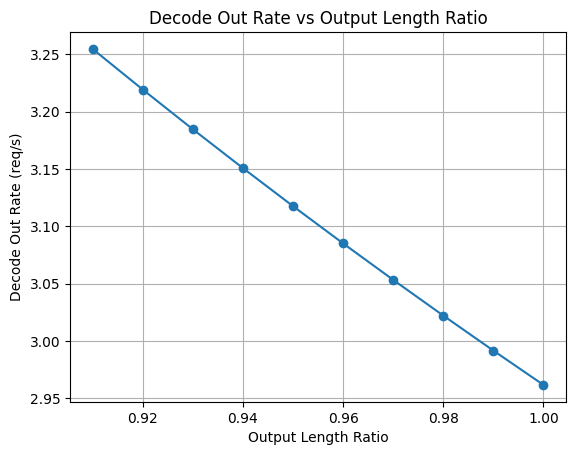

In [ ]:
rate_model = DisaggregationRateModel('llama-7b', 2, 128, 256)
res = []
output_len_ratios  = []

count = 10
start = 1 - count/100
for i in range(1, count+1):
    ratio = start + 0.01 * i
    output_len_ratios.append(ratio)
    rate_model = DisaggregationRateModel('llama-7b', 2, 128, 256, ratio)
    rate_model = DisaggregationRateModel('llama-7b', 2, 182, 473, ratio)
    res.append(rate_model.decode_model.get_out_rate())
plt.plot(output_len_ratios, res, marker='o')
plt.xlabel('Output Length Ratio')
plt.ylabel('Decode Out Rate (req/s)')
plt.title('Decode Out Rate vs Output Length Ratio')
plt.grid(True)
plt.show()


### Batch Size vs QPS

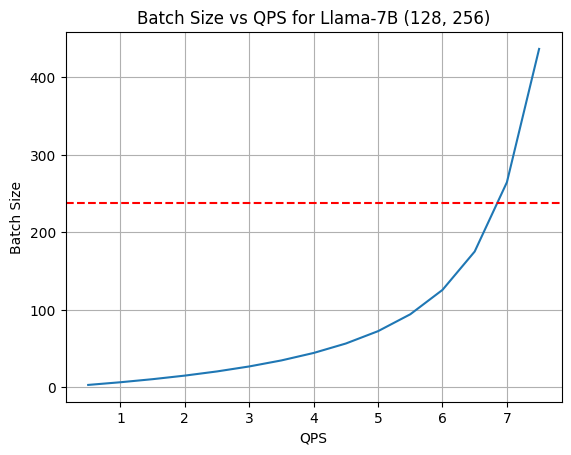

In [ ]:

m = DecodeRateModel('llama-7b', 2, 7.442236861472422, 128, 256)
m = DecodeRateModel('llama-7b', 2, 6.59744, 182, 473)
qps = []
res = []
input_len = 128
output_len = 256
for i in range(1, 16):
    i = i / 2
    m = DecodeRateModel('llama-7b', i, 7.442236861472422, input_len, output_len)
    # m = DecodeRateModel('llama-7b', i, 6.59744, 182, 473)
    res.append(m.get_batch_size_according_to_qps())
    qps.append(i)
decode_max_batch_size = m.get_max_batch_size()
plt.plot(qps, res)
plt.xlabel('QPS')
plt.ylabel('Batch Size')
plt.axhline(y=decode_max_batch_size, color='r', linestyle='--', label='Max Batch Size')
plt.title(f'Batch Size vs QPS for Llama-7B ({input_len}, {output_len})')
plt.grid(True)
plt.show()


### Max Prefill/Decode Rate vs Prompt Len

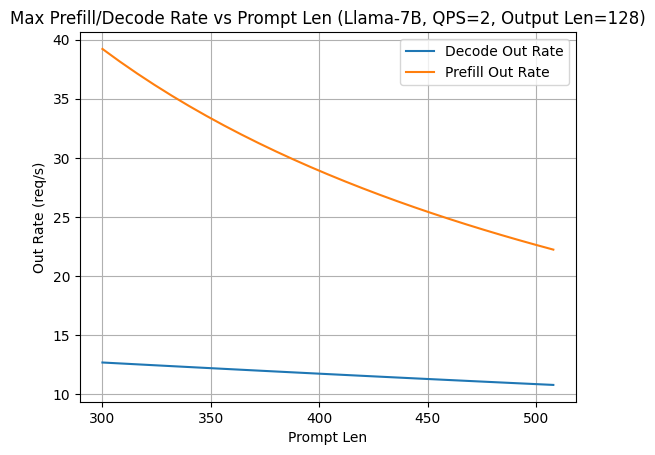

In [ ]:
max_decode_out_rate = []
max_prefill_out_rate = []
prompt_lens = range(300, 513, 8)
for i in prompt_lens:
    m = DisaggregationRateModel('llama-7b', 2, i, 128)
    max_decode_out_rate.append(m.decode_model.get_out_rate())
    max_prefill_out_rate.append(m.prefill_model.get_deal_max_rare())
plt.plot(prompt_lens, max_decode_out_rate, label='Decode Out Rate')
plt.plot(prompt_lens, max_prefill_out_rate, label='Prefill Out Rate')
plt.xlabel('Prompt Len')
plt.ylabel('Out Rate (req/s)')
plt.title('Max Prefill/Decode Rate vs Prompt Len (Llama-7B, QPS=2, Output Len=128)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def calculate_avg_step_time(results):
    # 计算每个inference_type和token_num的平均step_time
    avg_results = {
        'prefill': {},
        'decode': {},
    }
    for inference_type in results:
        for token_num, step_times in results[inference_type].items():
            step_times = np.array(step_times, dtype=float)
            avg_step_time = mean(step_times)
            avg_results[inference_type][token_num] = avg_step_time
    return avg_results

# 拟合token_num和avg_step_time的关系
def fit_token_num_vs_avg_step_time(token_nums, avg_step_times, inference_type):

    if len(token_nums) < 2:
        print(f"Not enough data to fit for {inference_type}.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    if inference_type == 'prefill':
        # 线性拟合
        coefficients = np.polyfit(token_nums, avg_step_times, 2)
    elif inference_type == 'decode':
        # 二次多项式拟合
        coefficients = np.polyfit(token_nums, avg_step_times, 2)
    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_token_num_vs_avg_step_time(results):
    avg_results = calculate_avg_step_time(results)
    # 分配两个子图
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    for i, inference_type in enumerate(avg_results):
        token_nums = list(avg_results[inference_type].keys())
        avg_step_times = list(avg_results[inference_type].values())

        token_nums = np.array(token_nums, dtype=float)
        avg_step_times = np.array(avg_step_times, dtype=float)

        sort_idx = np.argsort(token_nums)
        token_nums = token_nums[sort_idx]
        avg_step_times = avg_step_times[sort_idx]

        # 剔除异常值
        if len(token_nums) > 2:
            # 基于IQR方法剔除异常值
            q1 = np.percentile(avg_step_times, 25)
            q3 = np.percentile(avg_step_times, 75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
            mask = (avg_step_times >= lower_bound) & (avg_step_times <= upper_bound)
            token_nums = token_nums[mask]
            avg_step_times = avg_step_times[mask]
        axs[i].scatter(token_nums, avg_step_times, label=f'{inference_type} data', color='red', s=10)
        # 拟合曲线
        fit_results = fit_token_num_vs_avg_step_time(token_nums, avg_step_times, inference_type)
        if fit_results is not None:
            print(f'Fitting results for {inference_type}: {fit_results}')
            fit_line = np.polyval(fit_results, token_nums)
            axs[i].plot(token_nums, fit_line, label=f'{inference_type} fit', color='orange')
        axs[i].set_title(f'Token Num vs Avg Step Time for {inference_type}')
        axs[i].set_xlabel('Token Num')
        axs[i].set_ylabel('Avg Step Time (ms)')
        axs[i].legend()
        axs[i].grid(True)
    plt.tight_layout()
    plt.savefig(f'token_num_vs_avg_step_time.png')
    plt.show()
    
results = {        # [inference_type][token_num] = step_time:list
    'prefill': {},
    'decode': {},
}
for concurrency in [1, 2, 4, 8]:
    print(f"Processing concurrency: {concurrency}")
    instance_file_dir = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-{concurrency}-pdd-4/llama-7b/poisson'
    instance_profile = InstanceProfile(instance_file_dir, enable_pd=True)
    instance_profile.get_pdd_instance_info()
    # instance_profile.plot_token_num_vs_avg_step_time()
    for inference_type in instance_profile.results:
        print(f'Inference Type: {inference_type}')
        for token_num, avg_step_time in instance_profile.results[inference_type].items():
            if token_num not in results[inference_type]:
                results[inference_type][token_num] = []
            results[inference_type][token_num].extend(instance_profile.results[inference_type][token_num])
plot_token_num_vs_avg_step_time(results)

### not pd 建模

In [ ]:
class AggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg):
        self.in_rate = workload_msg['qps']
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_prefill_args = model_profiler_msg['prefill_msg']
        self.fit_decode_args = model_profiler_msg['decode_msg']

        gpu_block_num = model_profiler_msg['model_msg']['gpu_block']
        self.max_batch_size = gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        self.max_seq_len = model_profiler_msg['model_msg']['max_seq_len']

    def get_in_rate(self):
        return self.in_rate

    def get_prefill_time(self, token_num=None):
        # y = a*x^2 + b*x + c
        latency_args = self.fit_prefill_args
        time = 0
        while token_num > self.max_seq_len:
            time += latency_args[0] * self.max_seq_len**2 + latency_args[1] * self.max_seq_len + latency_args[2]
            token_num -= self.max_seq_len
        # 计算剩余token_num的时间
        time += latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
        return time
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len

    def get_decode_time(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_decode_args
        print((args[0] * batch_size + args[1] * self.get_seq_len() + args[2]))
        time = (args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len
        return time

    # def get_deal_rare(self):
    #     args = self.fit_args
    #     return 1000 / (args[0] * self.prompt_len**2 + args[1]*self.prompt_len + args[2])
    
    def get_out_rate(self, batch_size):
        # print(self.get_prefill_time(self.prompt_len*batch_size),
        #       self.get_prefill_time(self.prompt_len) * batch_size, 
        #       self.get_prefill_time(self.prompt_len*self.in_rate),
        #       self.get_prefill_time(self.prompt_len)*self.in_rate,
        #       self.get_prefill_time(508))
        prefill_time = self.get_prefill_time(batch_size * self.prompt_len)       # 391.22709043703503 0.2431446590704659
        # prefill_time = self.get_prefill_time(508)                               # 146.6184449543714 0.24557897232779077
        # prefill_time = self.get_prefill_time(self.prompt_len)*batch_size    # 568.8139697206962 0.24140735889278755
        print(prefill_time, self.get_prefill_time(self.prompt_len))
        rate = batch_size / (prefill_time / 1000 + self.get_decode_time(batch_size) / 1000)
        return rate
    
m = ModelProfiler('llama-13b', profile_dir)
model_profiler_msg = m.profile_data
workload_msg = {
    'qps': 0.25,
    'prompt_len': 260,  # 182\260
    'output_len': 490,  # 473\490
}
rate_model = AggregationRateModel(model_profiler_msg, workload_msg)    # 182, 473
# print(rate_model.max_batch_size)
print(rate_model.get_out_rate(6))
# batch_size = [1, 2, 4, 8, 16, 32, 48, 64, 80, 96, 112, 128]
# out_rate = []
# for bs in batch_size:
#     out_rate.append(rate_model.get_out_rate(bs))
# plt.plot(batch_size, out_rate, marker='o')
# plt.axhline(y=rate_model.get_in_rate(), color='r', linestyle='--', label='Input Rate')
# plt.xlabel('Batch Size')
# plt.ylabel('Out Rate (req/s)')
# plt.title('Out Rate vs Batch Size')
# plt.legend()
# plt.grid(True)
# plt.show()

782.4541808740701 94.8023282867827
49.56212407143107
0.23934997357274107
